# 方向 vs 幅值的球面包裹 3D 论证图

用 autos(方向主导)与 wbc(幅值主导)一对一对照,论证 SCMK 融合方向+幅值的必要性。

**几何直觉**:正常样本所在的单位球面 = L2 归一化嵌入(方向);半径 = 投影幅值(对数压缩, 正常≈1 贴球壳)。
- 方向型异常 → 贴球面但偏到某一角区(角度分离)
- 幅值型异常 → 鼓出/飞离球面(径向分离)

**实测**:autos 异常半径≈1.08(贴球壳)、wbc 异常半径≈2.9(鼓出)。kernel 选 torch311。

In [ ]:
# 交互式 3D：运行后下方球面图可用鼠标拖动旋转。
# 拖到满意角度后，在新 cell 运行下一格读出 (elev, azim)，填回 VIEWS。
# 若想回到静态嵌入图，把本行改成 %matplotlib inline 重跑。
%matplotlib widget

In [7]:
import os, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
from sklearn.decomposition import PCA

NB = 'C:/OD/Shihao/5/Granular-CMK/hybrid_score'
if NB not in sys.path:
    sys.path.insert(0, NB)
from run_hybrid_score import (load_data, gauss_med_kernels, extract_components,
                              _best_ocsvm_scores, _minmax, NU_CANDIDATES)
from CMK_OCSVM import TRAIN_CFG
from CMK_OCSVM_scatter import train_cmk_scatter

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
DATA_ROOT = 'C:/OD/Shihao/datasets'
OUT = 'C:/OD/Shihao/5/result/hybrid_score'
dev = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
best = pd.read_csv('C:/OD/Shihao/5/result/hybrid_score/hybrid_best.csv')
CFG = {r.dataset: (int(r.best_dim), float(r.best_lambda)) for r in best.itertuples()}

def prep(stem):
    dim, lam = CFG[stem]
    X, y, _ = load_data(os.path.join(DATA_ROOT, stem + '.mat'))
    ker = gauss_med_kernels(X[y == 0])
    m = train_cmk_scatter(X, y, ker, dim, dev, {**TRAIN_CFG, 'lambda_scatter': lam})
    Hn, Hnorms = extract_components(m, X, dev)
    Hdir = np.concatenate(Hn, 1)
    xy = PCA(2).fit_transform(Hdir)
    u3 = PCA(3).fit_transform(Hdir)
    u3 = u3 / (np.linalg.norm(u3, axis=1, keepdims=True) + 1e-9)
    z = Hnorms.mean(1)
    rn = 1.0 + np.log(z / (np.median(z[y == 0]) + 1e-9) + 1e-9)
    rn = np.clip(rn, 0.2, None)
    return dict(xy=xy, u3=u3, z=z, rn=rn, y=y)

PANELS = [('autos_variant1', 'Autos  (direction-dominant)'),
          ('wbc_malignant_39_variant1', 'WBC  (magnitude-dominant)')]
DATA = {s: prep(s) for s, _ in PANELS}

# 单位参考球网格
uu = np.linspace(0, 2 * np.pi, 48); vv = np.linspace(0, np.pi, 24)
SX = np.outer(np.cos(uu), np.sin(vv))
SY = np.outer(np.sin(uu), np.sin(vv))
SZ = np.outer(np.ones_like(uu), np.cos(vv))
print('prepared:', list(DATA))

prepared: ['autos_variant1', 'wbc_malignant_39_variant1']


## 球面包裹视图(主图)

球壳 = 正常样本的单位范数(方向);半径 = 1+log(幅值)。autos 异常贴球面偏角、wbc 异常鼓出飞离。

In [ ]:
# 鼠标拖动上面的球面图到满意角度后，运行本格读出当前 (elev, azim)：
for ax, (stem, _) in zip(fig.axes, PANELS):
    print(f"{stem}: ({round(ax.elev)}, {round(ax.azim)})")
# 把打印结果填回上一格的 VIEWS = {...} 即可固定该视角（再切回 %matplotlib inline 出静态图）。

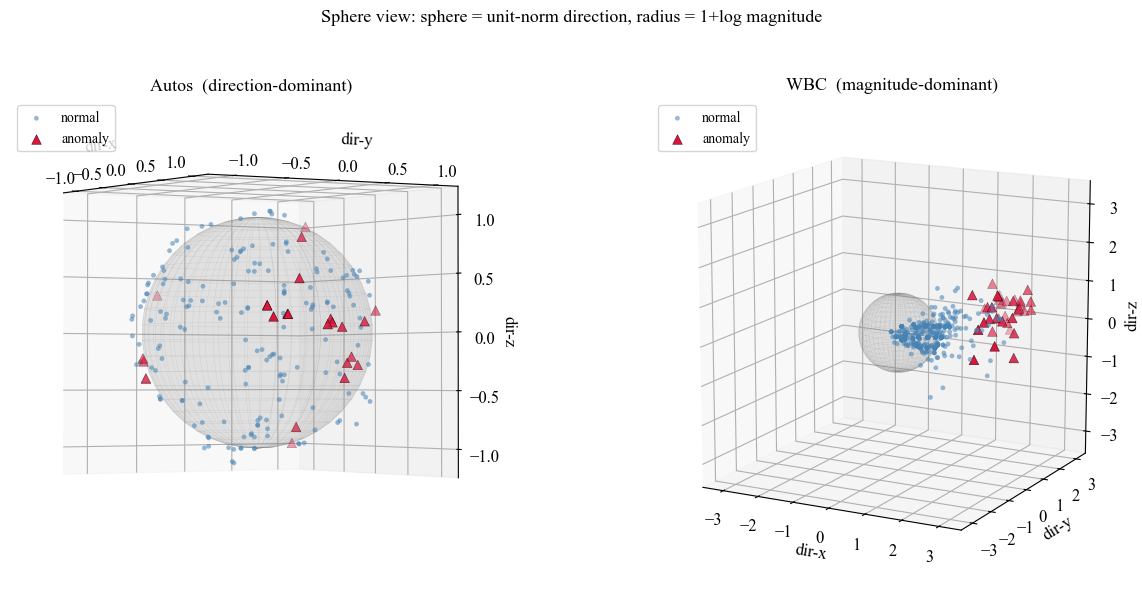

In [ ]:
# 每个子图独立视角(可调)：(elev, azim)。参考 result/hybrid_score/_view_scan_autos.png 挑选
VIEWS = {'autos_variant1': (-1, -32), 'wbc_malignant_39_variant1': (14, -62)}

fig = plt.figure(figsize=(13, 6))
for i, (stem, title) in enumerate(PANELS):
    d = DATA[stem]; y = d['y']; no = y == 0; an = y == 1
    P = d['rn'][:, None] * d['u3']
    ax = fig.add_subplot(1, 2, i + 1, projection='3d')
    ax.plot_surface(SX, SY, SZ, color='gray', alpha=0.10, linewidth=0, shade=False)
    ax.plot_wireframe(SX, SY, SZ, color='gray', alpha=0.18, linewidth=0.3)
    ax.scatter(P[no, 0], P[no, 1], P[no, 2], c='steelblue', s=12, alpha=0.55,
               edgecolors='none', label='normal')
    ax.scatter(P[an, 0], P[an, 1], P[an, 2], c='crimson', s=48, marker='^',
               edgecolors='k', linewidths=0.3, label='anomaly')
    rmax = max(1.2, d['rn'][an].max() * 1.05)
    ax.set_xlim(-rmax, rmax); ax.set_ylim(-rmax, rmax); ax.set_zlim(-rmax, rmax)
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel('x', labelpad=1); ax.set_ylabel('y', labelpad=1)
    ax.set_zlabel('z', labelpad=1)
    ax.set_title(title, fontsize=13)
    ax.view_init(*VIEWS[stem])
    ax.legend(loc='upper left', fontsize=10)
fig.suptitle('Sphere view: sphere = unit-norm direction, radius = 1+log magnitude',
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT + '/fig_3d_sphere.png', dpi=200, bbox_inches='tight')
fig.savefig(OUT + '/fig_3d_sphere.pdf', bbox_inches='tight')
plt.show()

## (可选)平面分布视图

x,y = 方向 PCA 2D;z = 幅值(min-max)。与球面图等价,作补充对照。

In [ ]:
fig = plt.figure(figsize=(13, 5.5))
for i, (stem, title) in enumerate(PANELS):
    d = DATA[stem]; y = d['y']; no = y == 0; an = y == 1
    z = _minmax(d['z'])
    ax = fig.add_subplot(1, 2, i + 1, projection='3d')
    ax.scatter(d['xy'][no, 0], d['xy'][no, 1], z[no], c='steelblue', s=12,
               alpha=0.45, edgecolors='none', label='normal')
    ax.scatter(d['xy'][an, 0], d['xy'][an, 1], z[an], c='crimson', s=44,
               marker='^', edgecolors='k', linewidths=0.3, label='anomaly')
    ax.set_xlabel('Direction PC1', labelpad=2)
    ax.set_ylabel('Direction PC2', labelpad=2)
    ax.set_zlabel('Magnitude (norm)', labelpad=2)
    ax.set_title(title, fontsize=13)
    ax.view_init(elev=16, azim=-60)
    ax.legend(loc='upper left', fontsize=10)
fig.suptitle('(Optional) Flat view: direction plane (x,y) vs magnitude height (z)',
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT + '/fig_3d_distribution.png', dpi=200, bbox_inches='tight')
plt.show()